# DDPM Disaster Data Exploratory Analysis
## CRI Phase 1: Disaster Dashboard Baseline

This notebook explores the DDPM Master Village Disaster Statistics (B.E. 2557-2567). 
We use the **Forensic Auditor** identity to audit sparsity and summarize impact across five thematic groups.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib as mpl
from matplotlib import font_manager
from cycler import cycler

# Set plotting style
plt.style.use('ggplot')

# --- Palette (blue-focused, from provided swatches) ---
CRI_BLUE_PALETTE = [
    '#142459',  # deep navy
    '#176BA0',  # steel blue
    '#19AADE',  # bright blue
    '#1AC9E6',  # cyan
    '#1DE4BD',  # teal
    '#6DFDD2',  # mint
    '#C7F9EE',  # very light mint
]
sns.set_palette(CRI_BLUE_PALETTE)
mpl.rcParams['axes.prop_cycle'] = cycler(color=CRI_BLUE_PALETTE)

# --- Global readability tuning: more whitespace + +2pt text sizes ---
# (a) Increase font sizes (roughly +2pt from Matplotlib defaults)
mpl.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'figure.titlesize': 20,
})

# (b) Squeeze axes area to leave more margin for titles/labels/ticklabels
mpl.rcParams.update({
    'figure.subplot.left': 0.12,
    'figure.subplot.right': 0.82,
    'figure.subplot.bottom': 0.16,
    'figure.subplot.top': 0.86,
    'axes.titlepad': 18,
    'axes.labelpad': 14,
})

# --- Thai text rendering fix (Matplotlib fonts) ---
# DejaVu Sans (default) often lacks Thai glyphs -> warnings + missing text.
# We pick the first available Thai-capable font from a short candidate list.
thai_font_candidates = [
    'TH Sarabun New',
    'Sarabun',
    'Noto Sans Thai',
    'Tahoma',
    'Angsana New',
    'Cordia New',
]
available_fonts = {f.name for f in font_manager.fontManager.ttflist}
thai_font = next((_f for _f in thai_font_candidates if _f in available_fonts), None)
if thai_font is not None:
    mpl.rcParams['font.family'] = thai_font
mpl.rcParams['axes.unicode_minus'] = False

# Absolute Path (Update if working on a different machine)
DATA_PATH = r"C:\Users\sitth\OracleWorkspace\Arun_Creagy\ψ\incubate\DCCE\CRI\data_system\data\1_silver\ddpm\master_village_disaster_stat_2557_2567.csv"
HAZARD_DIM_PATH = r"C:\Users\sitth\OracleWorkspace\Arun_Creagy\ψ\incubate\DCCE\CRI\data_system\data\2_gold\dim_hazard_canonical.csv"

print(f"Loading dataset: {DATA_PATH}")
try:
    # Standard Thai encoding for Windows-generated files
    df = pd.read_csv(DATA_PATH, encoding='cp874')
except Exception:
    df = pd.read_csv(DATA_PATH, encoding='utf-8')

# --- Filter for plotting: climate-related hazards only (refer to hazard dim table) ---
# Source of truth: [`dim_hazard_canonical.csv`](../../data/2_gold/dim_hazard_canonical.csv)
haz_dim = pd.read_csv(HAZARD_DIM_PATH, encoding='utf-8-sig')
climate_hazards_th = set(haz_dim.loc[haz_dim['hazard_group'].eq('climate'), 'canonical_hazard_name_th'].dropna().astype(str))

# DDPM labels sometimes contain variants (e.g., 'ดินโคลนถล่ม/ดินถล่ม'); handle via contains.
def _is_climate_hazard(series: pd.Series) -> pd.Series:
    s = series.astype(str).fillna('')
    return (
        s.isin(climate_hazards_th)
        | s.str.contains('ดินถล่ม|ดินโคลนถล่ม', regex=True)
    )

df_plot = df[_is_climate_hazard(df['Disaster Type'])].copy()

print(f"Dataset Shape: {df.shape}")
print(f"Plotting (climate hazards only) Shape: {df_plot.shape}")
df.head()

Loading dataset: C:\Users\sitth\OracleWorkspace\Arun_Creagy\ψ\incubate\DCCE\CRI\data_system\data\1_silver\ddpm\master_village_disaster_stat_2557_2567.csv


C:\Users\sitth\AppData\Local\Temp\ipykernel_13204\3600407238.py:74: DtypeWarning: Columns (0: Subdistrict Code, 1: Moo) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_PATH, encoding='utf-8')


Dataset Shape: (209935, 44)
Plotting (climate hazards only) Shape: (193315, 44)


,Incident Name,ปี,Disaster Type,Disaster Date,Province Code,Province,District Code,District,Subdistrict Code,Subdistrict,...,Livestock Damage,Fishing Damage,Transport Damage,Health Damage,Culture Damage,Education/Sports,Utilities Damage,Govt Property Damage,Other Public Benefits_1,Other Public Benefits_2
0,ปี 2557 ภัยแล้ง,2557,ภัยแล้ง,17/2/2014,33,ศรีสะเกษ,3322,ศิลาลาด,332204,โจดม่วง,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,ปี 2557 ภัยแล้ง,2557,ภัยแล้ง,17/2/2014,33,ศรีสะเกษ,3322,ศิลาลาด,332204,โจดม่วง,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,ปี 2557 ภัยแล้ง,2557,ภัยแล้ง,17/2/2014,33,ศรีสะเกษ,3322,ศิลาลาด,332204,โจดม่วง,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,ปี 2557 ภัยแล้ง,2557,ภัยแล้ง,24/2/2014,60,นครสวรรค์,6005,บรรพตพิสัย,600511,หนองตางู,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,ปี 2557 ภัยแล้ง,2557,ภัยแล้ง,24/2/2014,60,นครสวรรค์,6005,บรรพตพิสัย,600511,หนองตางู,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 1. Variable Grouping
We categorize the columns into functional groups to manage the 'mess' and focus on dashboard metrics.

In [2]:
groups = {
    'Temporal & Event': ['Disaster Type', 'Incident Name', 'Disaster Date', 'End Disaster Date', 'Cause', 'Situation', 'ปี', 'Status', 'Title'],
    'Human Impact': ['Affected Households', 'Affected People', 'Deaths', 'Injured', 'Missing', 'Evacuated Households', 'Evacuated People'],
    'Sectoral Damage': ['Agriculture Damage', 'Housing Damage', 'Livestock Damage', 'Fishing Damage', 'Business Damage', 'Utilities Damage', 'Transport Damage', 'Govt Property Damage', 'Health Damage', 'Education/Sports', 'Culture Damage', 'Other Public Benefits_1', 'Other Public Benefits_2'],
    'Geography': ['Province', 'Province Code', 'District', 'District Code', 'Subdistrict', 'Subdistrict Code', 'Moo', 'Village Code', 'Community'],
    'Administrative': ['Relief Declared Date', 'Disaster Area Date', 'Municipal Code', 'Municipality', 'Zone Center Name', 'Other Announce Date']
}

for g_name, g_cols in groups.items():
    found = [c for c in g_cols if c in df_plot.columns]
    print(f"{g_name}: {len(found)}/{len(g_cols)} columns found")

Temporal & Event: 9/9 columns found
Human Impact: 7/7 columns found
Sectoral Damage: 13/13 columns found
Geography: 9/9 columns found
Administrative: 6/6 columns found


## 2. Sparsity Audit (The 'Mess' Factor)
In DDPM data, a `0` value in an impact field usually means 'no data collected' rather than 'verified zero damage'. We audit the percentage of records that are effectively 'empty'.

In [3]:
def audit_sparsity(df, cols):
    results = []
    for col in cols:
        if col not in df.columns: continue
        
        if df[col].dtype in ['int64', 'float64']:
            # 0 or NaN is sparse
            empty_count = ((df[col].isna()) | (df[col] == 0)).sum()
        else:
            # Empty string or NaN is sparse
            empty_count = ((df[col].isna()) | (df[col].astype(str).str.strip() == '')).sum()
            
        results.append({
            'Column': col,
            'Sparse Pct': (empty_count / len(df)) * 100,
            'Valid Count': len(df) - empty_count
        })
    return pd.DataFrame(results).sort_values('Sparse Pct', ascending=False)

print("Top 10 Most Sparse Columns across all groups (climate hazards only):")
all_cols = [col for sublist in groups.values() for col in sublist]
audit_sparsity(df_plot, all_cols).head(10)

Top 10 Most Sparse Columns across all groups (climate hazards only):


,Column,Sparse Pct,Valid Count
43,Other Announce Date,100.000000,0
13,Missing,99.995862,8
15,Evacuated People,99.993275,13
24,Health Damage,99.972584,53
12,Injured,99.854124,282
11,Deaths,99.808603,370
25,Education/Sports,99.639966,696
14,Evacuated Households,99.634276,707
23,Govt Property Damage,99.585650,801
21,Utilities Damage,99.272172,1407


## 2.1 Administrative Hierarchy Quality Audit
We check for legacy administrative terms ('King Amphoe') and missing standardized codes that might affect joining with other spatial datasets.

In [4]:
# Data Quality Check: Administrative Hierarchy
# 1. Count unique subdistricts (Tambons) in King Amphoe (กิ่งอำเภอ)
king_amphoe_mask = df['District'].str.startswith('กิ่ง', na=False)
king_amphoe_tambons = df[king_amphoe_mask][['Province', 'District', 'Subdistrict']].drop_duplicates()

# 2. Count unique subdistricts (Tambons) with missing or invalid Subdistrict Code
# Note: Some codes might be 0, empty string, or NaN
missing_code_mask = (df['Subdistrict Code'].isna()) | (df['Subdistrict Code'].astype(str).isin(['0', '0.0', '', 'nan']))
missing_code_tambons = df[missing_code_mask][['Province', 'District', 'Subdistrict']].drop_duplicates()

print(f"Total unique administrative units (Tambon-level records): {len(df[['Province', 'District', 'Subdistrict']].drop_duplicates())}")
print(f"Unique Tambons in King Amphoe (กิ่งอำเภอ): {len(king_amphoe_tambons)}")
print(f"Unique Tambons with missing/invalid Subdistrict Code: {len(missing_code_tambons)}")

if len(king_amphoe_tambons) > 0:
    print("\nSample Tambons in King Amphoe:")
    display(king_amphoe_tambons.head())

if len(missing_code_tambons) > 0:
    print("\nSample Tambons with missing/invalid Subdistrict Code:")
    display(missing_code_tambons.head())

# Check for records with both issues
both_mask = king_amphoe_mask & missing_code_mask
if both_mask.any():
    print(f"\nUnique Tambons with BOTH issues: {len(df[both_mask][['Province', 'District', 'Subdistrict']].drop_duplicates())}")

Total unique administrative units (Tambon-level records): 7267
Unique Tambons in King Amphoe (กิ่งอำเภอ): 0
Unique Tambons with missing/invalid Subdistrict Code: 0


## 3. Human Impact Summary
The core metrics for the Disaster Dashboard.

In [5]:
human_cols = [c for c in groups['Human Impact'] if c in df_plot.columns]
print("Statistics for Impacted Records (where Households > 0) (climate hazards only):")
df_plot[df_plot['Affected Households'] > 0][human_cols].describe().round(2).T

Statistics for Impacted Records (where Households > 0) (climate hazards only):


,count,mean,std,min,25%,50%,75%,max
Affected Households,132124.0,20.68,92.53,1.0,2.0,5.0,12.0,9642.0
Affected People,132124.0,11.59,148.47,0.0,0.0,0.0,0.0,28765.0
Deaths,132124.0,0.00,0.05,0.0,0.0,0.0,0.0,8.0
Injured,132124.0,0.00,0.06,0.0,0.0,0.0,0.0,12.0
Missing,132124.0,0.00,0.02,0.0,0.0,0.0,0.0,7.0
Evacuated Households,132124.0,0.04,1.25,0.0,0.0,0.0,0.0,189.0
Evacuated People,132124.0,0.00,0.36,0.0,0.0,0.0,0.0,91.0


## 4. Sectoral Damage Frequency
Which sectors get reported the most?

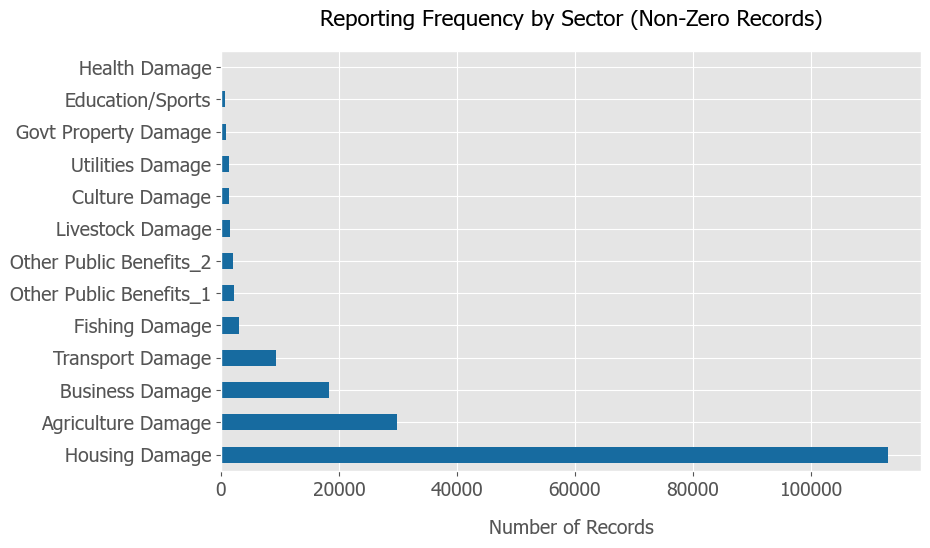

In [6]:
sector_cols = [c for c in groups['Sectoral Damage'] if c in df_plot.columns]
sector_freq = (df_plot[sector_cols] > 0).sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sector_freq.plot(kind='barh', color=CRI_BLUE_PALETTE[1])
plt.title('Reporting Frequency by Sector (Non-Zero Records)')
plt.xlabel('Number of Records')
plt.show()

## 5. Year-on-Year Trend
Volume of records by year (B.E.).

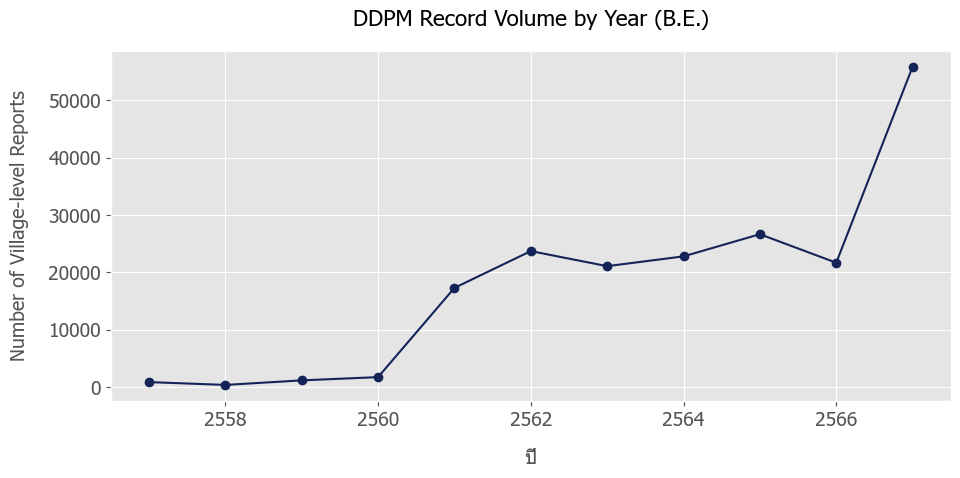

In [7]:
if 'ปี' in df_plot.columns:
    plt.figure(figsize=(12, 5))
    df_plot['ปี'].value_counts().sort_index().plot(kind='line', marker='o', color=CRI_BLUE_PALETTE[0])
    plt.title('DDPM Record Volume by Year (B.E.)')
    plt.ylabel('Number of Village-level Reports')
    plt.grid(True)
    plt.show()

## 6. Chiang Rai Province Deep-Dive (เชียงราย)
Filtering statistics specifically for Chiang Rai (Province Code 57) to understand its local disaster profile.

Total records for Chiang Rai (all years): 10896
Total records for Chiang Rai (excluding 2557): 10896
Note: Chiang Rai plots below are presented as '8-year disaster data'.
Most frequent disaster types in Chiang Rai:
Disaster Type (normalized)
วาตภัย         6863
อุทกภัย        3791
ดินโคลนถล่ม     230
ภัยหนาว           8
ภัยแล้ง           4
Name: count, dtype: int64


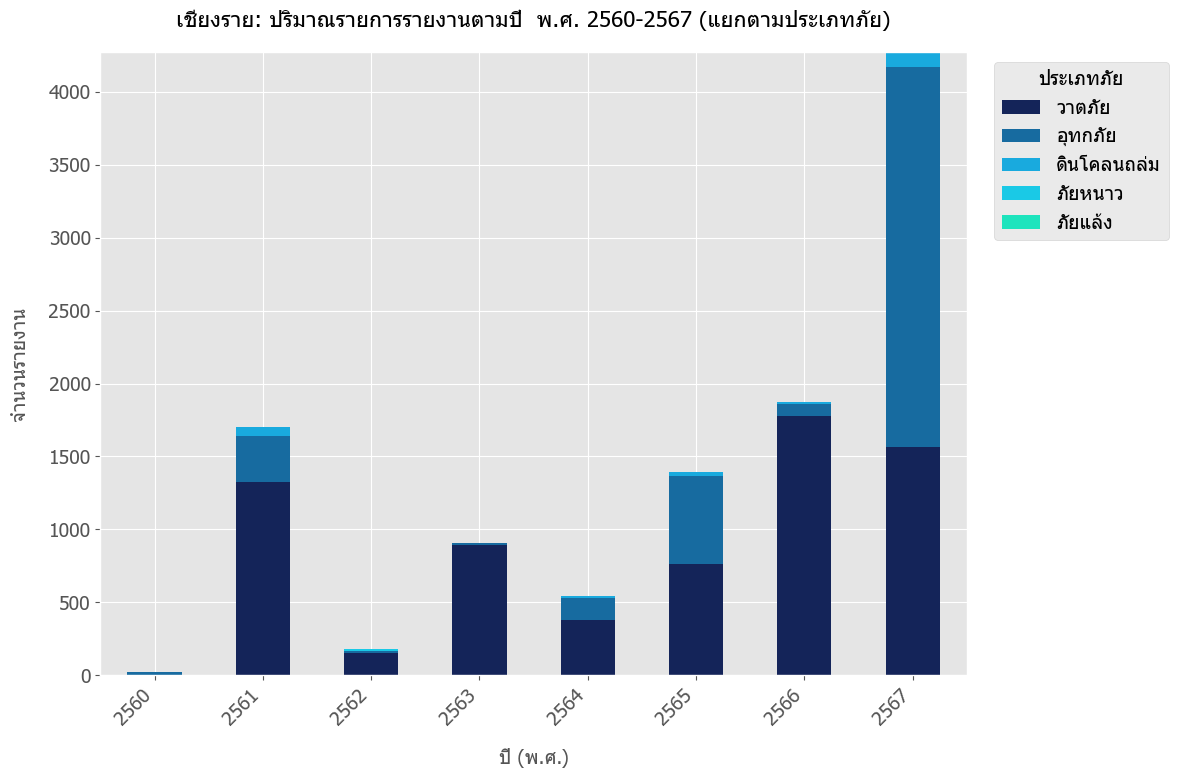

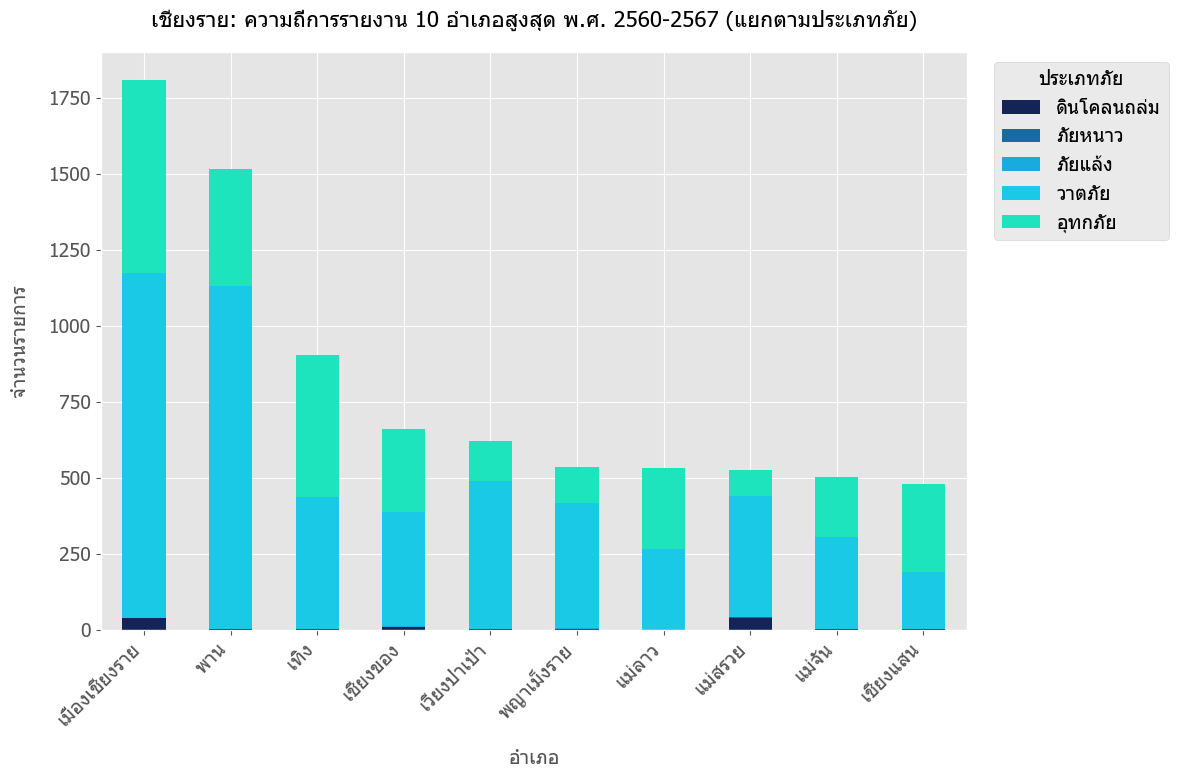

Chiang Rai: Human Impact Summary (Non-Zero Households):


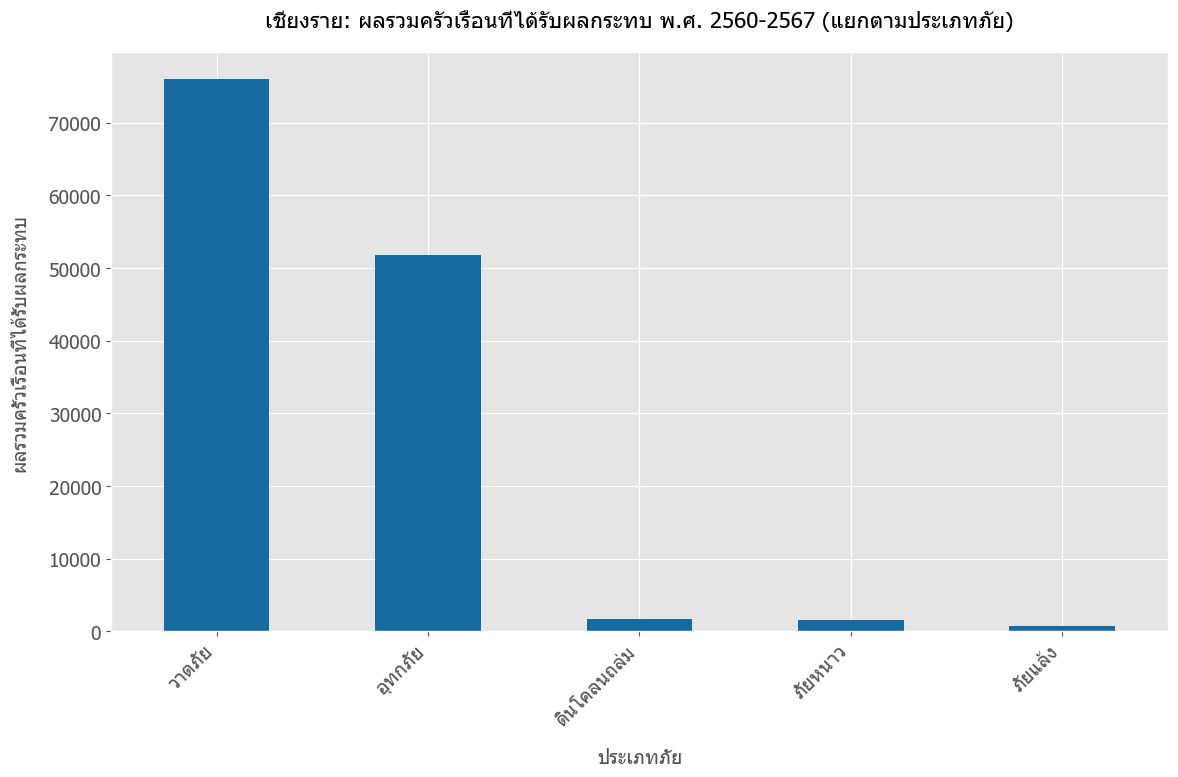

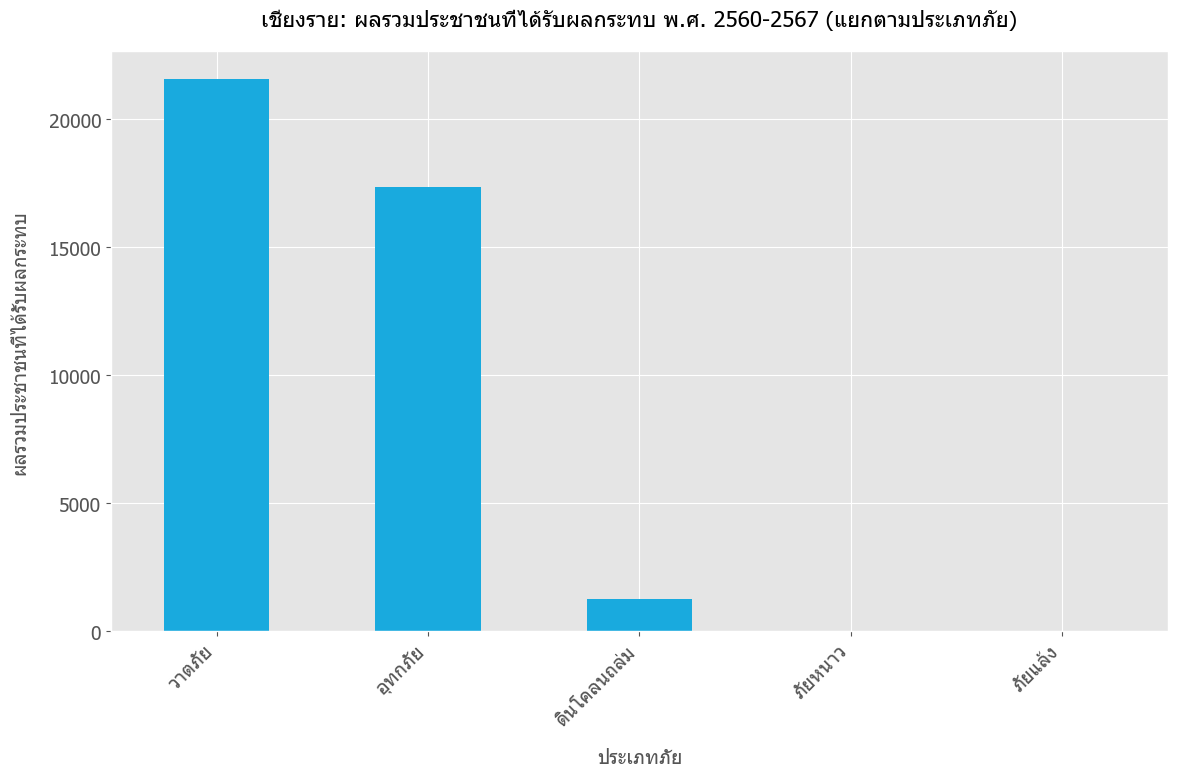

In [8]:
# Filter for Chiang Rai
# Note: Province Code might be numeric or string depending on how pandas loaded it.
# Safety: if you run this cell without re-running the first cell, ensure hazard normalization exists.
if 'Disaster Type (normalized)' not in df_plot.columns:
    df_plot['Disaster Type (normalized)'] = df_plot['Disaster Type'].astype(str).str.strip().replace({'ดินโคลนถล่ม/ดินถล่ม': 'ดินโคลนถล่ม'})
df_cr = df_plot[df_plot['Province Code'].astype(str).str.contains('57')].copy() # Chiang Rai province code (climate hazards only)

# Exclude B.E. 2557 from Chiang Rai plots/summary
df_cr_plot = df_cr[df_cr['ปี'].astype(str).ne('2557')].copy()

print(f"Total records for Chiang Rai (all years): {len(df_cr)}")
print(f"Total records for Chiang Rai (excluding 2557): {len(df_cr_plot)}")
print("Note: Chiang Rai plots below are presented as '8-year disaster data'.")
print(f"Most frequent disaster types in Chiang Rai:")
print(df_cr_plot['Disaster Type (normalized)'].value_counts().head(5))

# 6.1 Year-on-Year Trend for Chiang Rai (stacked by hazard type)
df_cr_plot['ปี_int'] = pd.to_numeric(df_cr_plot['ปี'], errors='coerce')
year_hazard = (
    df_cr_plot.dropna(subset=['ปี_int'])
      .groupby(['ปี_int', 'Disaster Type (normalized)'])
      .size()
      .unstack(fill_value=0)
)
year_hazard = year_hazard.sort_index()
# Order hazards by total volume (stable legend + nicer stacks)
year_hazard = year_hazard[year_hazard.sum().sort_values(ascending=False).index]
colors = [CRI_BLUE_PALETTE[i % len(CRI_BLUE_PALETTE)] for i in range(year_hazard.shape[1])]
ax = year_hazard.plot(kind='bar', stacked=True, figsize=(12, 8), color=colors)
plt.title('เชียงราย: ปริมาณรายการรายงานตามปี  พ.ศ. 2560-2567 (แยกตามประเภทภัย)')
plt.xlabel('ปี (พ.ศ.)')
plt.ylabel('จำนวนรายงาน')
plt.xticks(rotation=45, ha='right')
plt.legend(title='ประเภทภัย', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 6.2 Top Districts in Chiang Rai by Record Count
# Stacked bars: district (top 10) × hazard type (record counts)
top_districts = df_cr_plot['District'].value_counts().head(10).index
district_hazard = (
    df_cr_plot[df_cr_plot['District'].isin(top_districts)]
      .groupby(['District', 'Disaster Type (normalized)'])
      .size()
      .unstack(fill_value=0)
)
district_hazard = district_hazard.loc[top_districts]  # preserve top-10 order
ax = district_hazard.plot(kind='bar', stacked=True, figsize=(12, 8))
# Ensure our palette is used for the stacked segments
for i, container in enumerate(ax.containers):
    for patch in container:
        patch.set_facecolor(CRI_BLUE_PALETTE[i % len(CRI_BLUE_PALETTE)])
plt.title('เชียงราย: ความถี่การรายงาน 10 อำเภอสูงสุด พ.ศ. 2560-2567 (แยกตามประเภทภัย)')
plt.xlabel('อำเภอ')
plt.ylabel('จำนวนรายการ')
plt.xticks(rotation=45, ha='right')
plt.legend(title='ประเภทภัย', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 6.3 Human Impact Statistics for Chiang Rai
print("Chiang Rai: Human Impact Summary (Non-Zero Households):")
df_cr_plot[df_cr_plot['Affected Households'] > 0][human_cols].describe().round(2).T

# 6.4 Impact sums by hazard type (Chiang Rai)
impact_by_hazard = (
    df_cr_plot.groupby('Disaster Type (normalized)')[['Affected Households', 'Affected People']]
        .sum(numeric_only=True)
        .sort_values('Affected Households', ascending=False)
)

impact_by_hazard['Affected Households'].plot(kind='bar', figsize=(12, 8), color=CRI_BLUE_PALETTE[1])
plt.title('เชียงราย: ผลรวมครัวเรือนที่ได้รับผลกระทบ พ.ศ. 2560-2567 (แยกตามประเภทภัย)')
plt.xlabel('ประเภทภัย')
plt.ylabel('ผลรวมครัวเรือนที่ได้รับผลกระทบ')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

impact_by_hazard['Affected People'].plot(kind='bar', figsize=(12, 8), color=CRI_BLUE_PALETTE[2])
plt.title('เชียงราย: ผลรวมประชาชนที่ได้รับผลกระทบ พ.ศ. 2560-2567 (แยกตามประเภทภัย)')
plt.xlabel('ประเภทภัย')
plt.ylabel('ผลรวมประชาชนที่ได้รับผลกระทบ')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 7. Spatial Visualization: Chiang Rai Case Study
We map the disaster impact at the Tambon (Subdistrict) level to identify high-risk hotspots. We use a fallback matching strategy to ensure data from subdistricts with missing codes are still visualized.

In [9]:
import geopandas as gpd

SHP_PATH = r"C:\Users\sitth\OracleWorkspace\Arun_Creagy\ψ\incubate\DCCE\CRI\data_system\data\1_silver\dopa\tambon_boundaries_enriched.shp"

print("Aggregating subdistrict statistics...")
agg_stats = df_cr_plot.groupby(['Subdistrict Code', 'Subdistrict', 'District']).agg({
    'Affected Households': 'sum',
    'Affected People': 'sum',
    'Deaths': 'sum'
}).reset_index()

print("Calculating Avg YoY Change (2560-2567)...")
yoy_pivot = df_cr_plot[(df_cr_plot['ปี_int'] >= 2560) & (df_cr_plot['ปี_int'] <= 2567)].pivot_table(
    index=['Subdistrict Code', 'Subdistrict', 'District'], 
    columns='ปี_int', 
    values='Affected Households', 
    aggfunc='sum'
).fillna(0)

years = sorted(yoy_pivot.columns)
if len(years) > 1:
    yoy_diffs = [yoy_pivot[years[i+1]] - yoy_pivot[years[i]] for i in range(len(years)-1)]
    avg_yoy = pd.concat(yoy_diffs, axis=1).mean(axis=1).rename('Avg YoY Change')
    agg_stats = agg_stats.merge(avg_yoy, on=['Subdistrict Code', 'Subdistrict', 'District'], how='left')
else:
    agg_stats['Avg YoY Change'] = 0
agg_stats['Avg YoY Change'] = agg_stats['Avg YoY Change'].fillna(0)

print("Loading shapefile and matching geometries...")
gdf = gpd.read_file(SHP_PATH)
gdf_cr = gdf[gdf['P_NAME_T'] == 'เชียงราย'].copy()

# Matching Logic
agg_stats['match_id'] = agg_stats['Subdistrict Code'].astype(str).str.split('.').str[0]
gdf_cr['match_id'] = gdf_cr['subdist_cd'].astype(str)
merged = gdf_cr.merge(agg_stats, on='match_id', how='left')

# Fallback by Name
unmatched_mask = merged['Affected Households'].isna()
if unmatched_mask.any():
    print(f"Fallback matching for {unmatched_mask.sum()} tambons by name...")
    name_map = agg_stats.drop_duplicates('Subdistrict').set_index('Subdistrict')
    for idx in merged[unmatched_mask].index:
        t_name = str(merged.at[idx, 'T_NAME_T']).strip()
        if t_name in name_map.index:
            for col in ['Affected Households', 'Affected People', 'Deaths', 'Avg YoY Change']:
                merged.at[idx, col] = name_map.at[t_name, col]

target_cols = ['Affected Households', 'Affected People', 'Deaths', 'Avg YoY Change']
merged[target_cols] = merged[target_cols].fillna(0)
print("Geographic matching complete.")

Aggregating subdistrict statistics...
Calculating Avg YoY Change (2560-2567)...
Loading shapefile and matching geometries...
Fallback matching for 8 tambons by name...
Geographic matching complete.


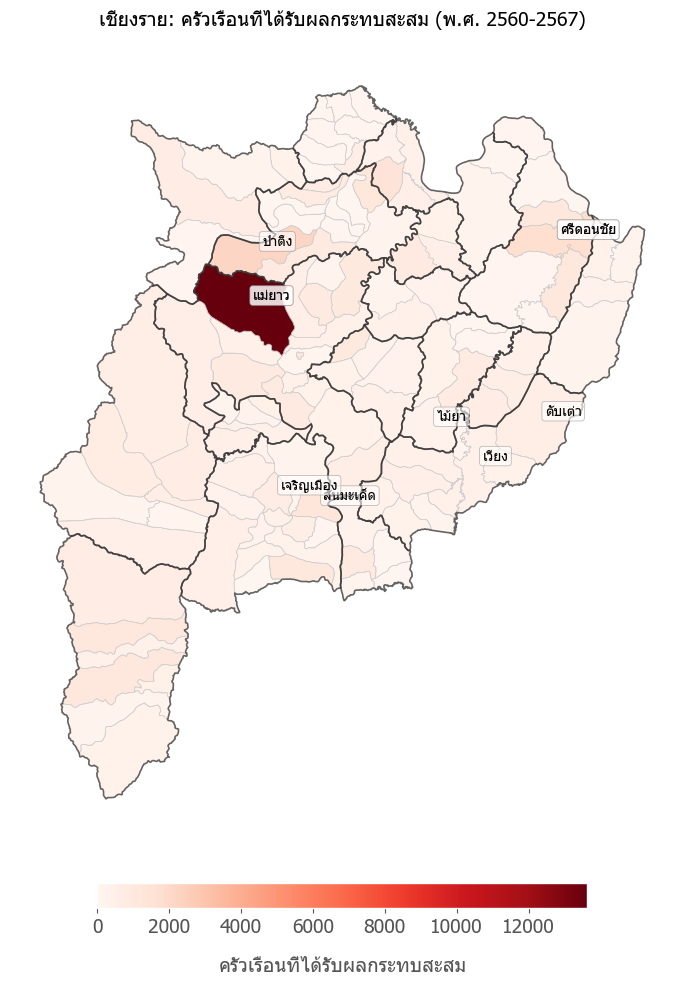

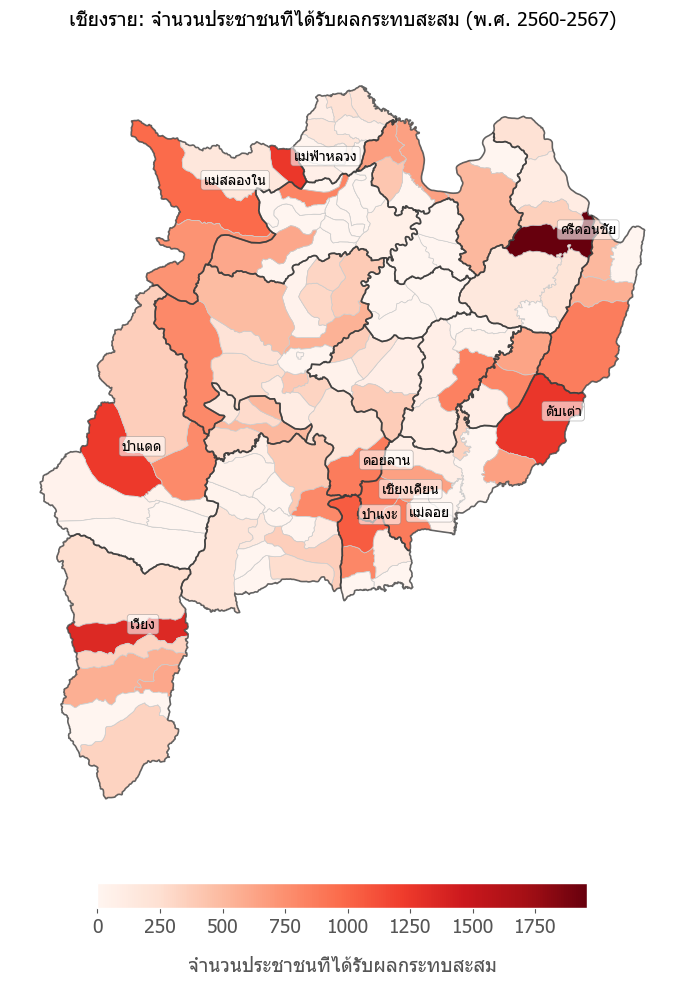

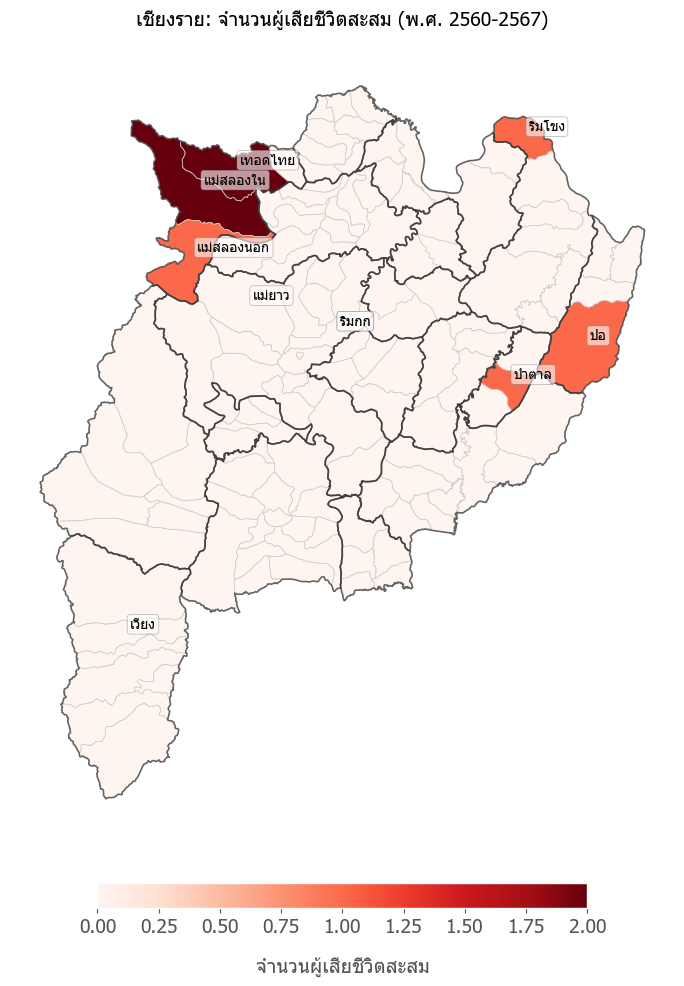

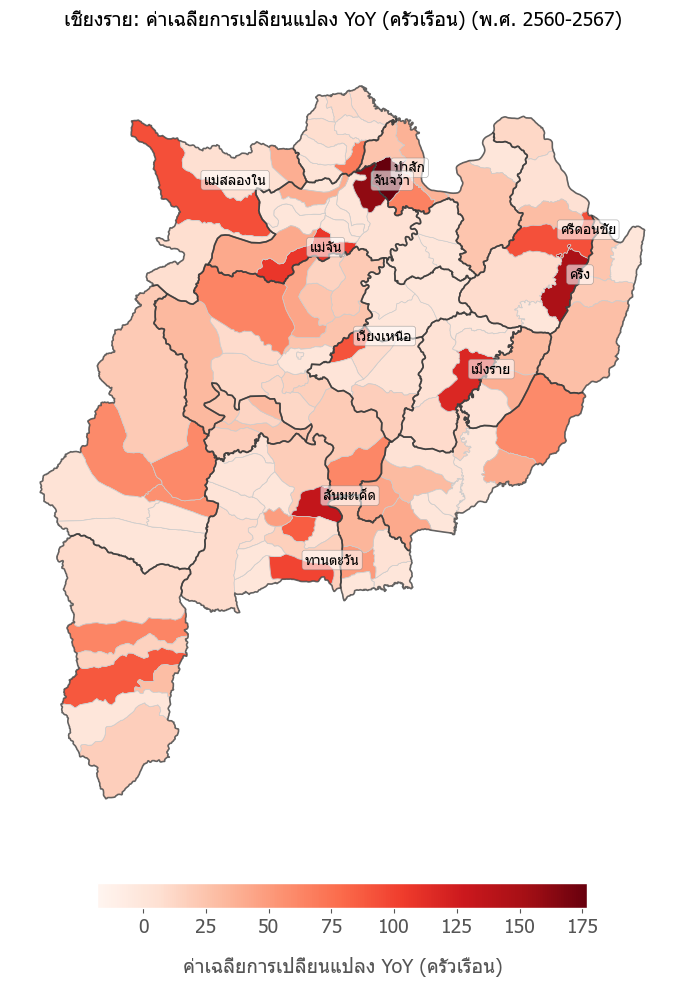

In [10]:
# Plotting the Maps
districts = merged.dissolve(by='A_NAME_T')

map_tasks = [
    ('Affected Households', 'ครัวเรือนที่ได้รับผลกระทบสะสม'),
    ('Affected People', 'จำนวนประชาชนที่ได้รับผลกระทบสะสม'),
    ('Deaths', 'จำนวนผู้เสียชีวิตสะสม'),
    ('Avg YoY Change', 'ค่าเฉลี่ยการเปลี่ยนแปลง YoY (ครัวเรือน)')
]

for col, title in map_tasks:
    fig, ax = plt.subplots(1, 1, figsize=(14, 14))
    
    # Plot Tambon Choropleth
    merged.plot(column=col, ax=ax, cmap='Reds', legend=True, 
                edgecolor='0.8', linewidth=0.5,
                legend_kwds={'label': title, 'orientation': "horizontal", 'shrink': 0.5, 'pad': 0.05})
    
    # Overlay District Boundaries
    districts.boundary.plot(ax=ax, color='#333333', linewidth=1.2, alpha=0.7)
    
    # Annotate Top 10 Tambons
    top_10 = merged.nlargest(10, col)
    for idx, row in top_10.iterrows():
        centroid = row['geometry'].centroid
        ax.annotate(text=row['T_NAME_T'], xy=(centroid.x, centroid.y),
                    xytext=(4, 4), textcoords="offset points",
                    fontsize=10, fontproperties=thai_font,
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6, ec='0.5'))

    ax.set_title(f"เชียงราย: {title} (พ.ศ. 2560-2567)", fontsize=18, fontproperties=thai_font)
    ax.set_axis_off()
    plt.show()